<a href="https://colab.research.google.com/github/Shahul187/aml-alert-triage/blob/main/notebooks/05_explainability.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [9]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import joblib

base = '/content/drive/MyDrive/aml-project/'
xgb2 = joblib.load(base + 'xgb_model.pkl')
test_f = pd.read_parquet(base + 'test_features.parquet')
p2 = np.load(base + 'test_scores.npy')

FEATURES_V2 = xgb2.get_booster().feature_names
X_test = test_f[FEATURES_V2]
y_test = test_f['Is_laundering']

print(f"{len(X_test):,} test rows | {len(FEATURES_V2)} features")
print(f"Scores loaded: min {p2.min():.4f}, max {p2.max():.4f}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
56,544 test rows | 22 features
Scores loaded: min 0.0000, max 1.0000


In [10]:
K = 0.05
n_top = int(len(p2) * K)
top_idx = np.argsort(-p2)[:n_top]

top = test_f.iloc[top_idx]
top_crime = top[top['Is_laundering'] == 1]
all_crime = test_f[test_f['Is_laundering'] == 1]

cov = pd.DataFrame({
    'in_test': all_crime['Laundering_type'].value_counts(),
    'caught_top5%': top_crime['Laundering_type'].value_counts()
}).fillna(0)
cov['caught_%'] = (cov['caught_top5%'] / cov['in_test'] * 100).round(1)
print(cov.sort_values('caught_%', ascending=False).to_string())

                      in_test  caught_top5%  caught_%
Laundering_type                                      
Structuring               231         213.0      92.2
Cash_Withdrawal           400         344.0      86.0
Smurfing                  102          82.0      80.4
Single_large               51          21.0      41.2
Deposit-Send              142          51.0      35.9
Fan_In                     21           3.0      14.3
Fan_Out                    49           6.0      12.2
Bipartite                  21           2.0       9.5
Layered_Fan_Out            40           3.0       7.5
Cycle                      37           2.0       5.4
Scatter-Gather             20           1.0       5.0
Stacked Bipartite          24           1.0       4.2
Behavioural_Change_1       83           0.0       0.0
Gather-Scatter             17           0.0       0.0
Behavioural_Change_2      124           0.0       0.0
Over-Invoicing             14           0.0       0.0
Layered_Fan_In             4

In [11]:
!pip install shap -q
import shap

sample_idx = np.random.default_rng(42).choice(len(X_test), 3000, replace=False)
X_sample = X_test.iloc[sample_idx]

explainer = shap.TreeExplainer(xgb2)
shap_values = explainer.shap_values(X_sample)

print(f"SHAP values: {shap_values.shape}")

SHAP values: (3000, 22)


In [12]:
K = 0.05
n_top = int(len(p2)*K)
top_mask = np.zeros(len(p2), dtype=bool)
top_mask[np.argsort(-p2)[:n_top]] = True

always = ((test_f['alert_r2']==1) | (test_f['alert_r1']==1)).values
hybrid = top_mask | always

for name, m in [('Model top 5%', top_mask), ('Hybrid (model + R1/R2)', hybrid)]:
    caught = y_test[m].sum()
    print(f"{name}: {m.sum():,} alerts | {caught:,} caught "
          f"({caught/y_test.sum()*100:.1f}% recall) | "
          f"{caught/m.sum()*100:.2f}% precision")

hy_cov = test_f[hybrid & (y_test==1)]['Laundering_type'].value_counts()
allc = test_f[y_test==1]['Laundering_type'].value_counts()
print("\nPatterns at 0% under model alone:")
for p in ['Over-Invoicing','Layered_Fan_In','Gather-Scatter','Behavioural_Change_2']:
    print(f"  {p:<22} {hy_cov.get(p,0):>3} / {allc.get(p,0):>3}")

Model top 5%: 2,827 alerts | 729 caught (51.5% recall) | 25.79% precision
Hybrid (model + R1/R2): 18,059 alerts | 847 caught (59.8% recall) | 4.69% precision

Patterns at 0% under model alone:
  Over-Invoicing          14 /  14
  Layered_Fan_In          10 /  40
  Gather-Scatter           1 /  17
  Behavioural_Change_2     0 / 124


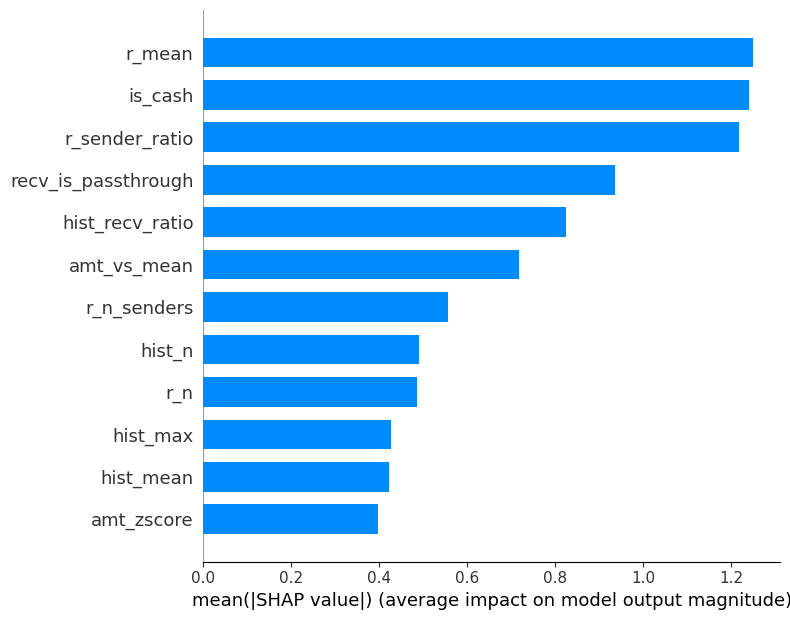

In [13]:
import matplotlib.pyplot as plt
shap.summary_plot(shap_values, X_sample, plot_type='bar', show=False, max_display=12)
plt.tight_layout()
plt.savefig(base + 'shap_importance.png', dpi=120, bbox_inches='tight')
plt.show()

In [14]:
def explain(row_pos, n=4):
    sv = explainer.shap_values(X_test.iloc[[row_pos]])[0]
    contrib = pd.Series(sv, index=FEATURES_V2).sort_values(key=abs, ascending=False)
    r = test_f.iloc[row_pos]
    print(f"score {p2[row_pos]:.3f} | actual {'LAUNDERING' if r['Is_laundering'] else 'clean'}"
          f" | {r.get('Laundering_type','')}")
    for f, v in contrib.head(n).items():
        print(f"   {'+' if v>0 else '-'} {f}: {X_test.iloc[row_pos][f]:.2f}  (impact {v:+.2f})")
    print()

for pos in np.argsort(-p2)[:3]:
    explain(pos)

score 1.000 | actual LAUNDERING | Cash_Withdrawal
   + r_sender_ratio: 0.07  (impact +3.14)
   + r_n: 14.00  (impact +1.74)
   + recv_is_passthrough: 1.00  (impact +1.73)
   + alert_r1: 1.00  (impact +1.54)

score 1.000 | actual LAUNDERING | Cash_Withdrawal
   + r_sender_ratio: 0.07  (impact +3.14)
   + recv_is_passthrough: 1.00  (impact +1.74)
   + r_n: 14.00  (impact +1.74)
   + alert_r1: 1.00  (impact +1.54)

score 1.000 | actual LAUNDERING | Cash_Withdrawal
   + r_sender_ratio: 0.05  (impact +3.11)
   + r_n: 21.00  (impact +1.71)
   + recv_is_passthrough: 1.00  (impact +1.63)
   + alert_r1: 1.00  (impact +1.56)



In [15]:
cols = ['Date','Amount','is_cash','is_crossborder','Is_laundering','Laundering_type']
out = test_f[cols].copy()
out['model_score'] = p2
out['in_top_5pct'] = top_mask.astype(int)
out['hybrid_flag'] = hybrid.astype(int)
out.to_csv(base + 'scored_alerts.csv', index=False)
cov.to_csv(base + 'model_pattern_coverage.csv')
print(f"Saved {len(out):,} scored alerts.")
print(out.columns.tolist())

Saved 56,544 scored alerts.
['Date', 'Amount', 'is_cash', 'is_crossborder', 'Is_laundering', 'Laundering_type', 'model_score', 'in_top_5pct', 'hybrid_flag']
